# Bitirme Çalışması — GNSS-IR Deniz Seviyesi Son Analizi

Bu defter, **PTLD00AUS** istasyonu için 2022 yılının ilk haftasında (DOY 001–007) üretilmiş
GNSS-IR reflektör yüksekliği kestirimlerini, bağımsız bir **mareograf (tide gauge)** deniz
seviyesi referansı ile karşılaştırır ve doğrular.

## Analiz akışı

1. **Veri yükleme** — İki dalga boyu grubu ayrı ayrı yüklenir:
   - **SWG** (Short Wavelength Group, kısa dalga boyu, 0.00–0.20 m)
   - **LWG** (Long Wavelength Group, uzun dalga boyu, 0.20–0.50 m)

   ve mareograf deniz seviyesi referansı (`porl_tg_2022001_2022007.csv`).

2. **Mareograf enterpolasyonu** — Mareograf verisi ~1 dakika aralıklıdır; GNSS-IR çözümleri
   ise düzensiz `epochMean` zamanlarındadır. Mareograf değerleri, her GNSS-IR epoch'una
   doğrusal enterpolasyon ile taşınır.

3. **Düşey Yerel Bağlantı (Vertical Local Tie, VLT)** — GNSS anteninin faz merkezi (APC) ile
   mareograf sıfır noktası (TGZ) arasındaki düşey mesafe, her grup için ayrı hesaplanır:
   \[ \mathrm{VLT} = \mathrm{median}\big(h + SL_{tg}\big) \]

4. **GNSS-IR deniz seviyesi** — \[ SL_{GNSS\text{-}IR} = \mathrm{VLT} - h \]

5. **Zaman serisi grafikleri** — Mareograf çizgi, GNSS-IR ise üzerine saçılım (scatter).

6. **Saçılım grafiği ve regresyon** — GNSS-IR (yatay) vs mareograf (düşey), eğim ve uyum.

7. **İstatistik tablosu** — Korelasyon, KOH (RMSE) ve bias (ortalama hata), SWG/LWG için ayrı.

> **Not:** `h`, antenin faz merkezinden su yüzeyine olan düşey reflektör yüksekliğidir;
> deniz yükseldikçe `h` küçülür. Bu nedenle deniz seviyesi `VLT − h` ile elde edilir.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# --- Resolve project root robustly (works regardless of the notebook CWD) ---
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "data" / "results"
TG_DIR = PROJECT_ROOT / "data" / "tg"
FIG_DIR = PROJECT_ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Toggle between quality-controlled (_QC) and raw result files.
# The final analysis uses the QC-filtered estimates (PBNR >= 4 and
# elevRange >= 5); set this to False to inspect the unfiltered results instead.
USE_QC = True
QC_TAG = "_QC" if USE_QC else ""

SWG_FILE = RESULTS_DIR / f"results_PTLD00AUS_2022001_2022007_30S_SWG{QC_TAG}.csv"
LWG_FILE = RESULTS_DIR / f"results_PTLD00AUS_2022001_2022007_30S_LWG{QC_TAG}.csv"
TG_FILE = TG_DIR / "porl_tg_2022001_2022007.csv"

# --- Thesis/report-quality plotting defaults ---
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
})

# Consistent colors across the whole analysis.
COLOR_TG = "#ff7f0e"    # tide gauge reference line (orange)
COLOR_SWG = "#1f77b4"   # SWG GNSS-IR estimates (blue)
COLOR_LWG = "#d62728"   # LWG GNSS-IR estimates (red)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"SWG_FILE     : {SWG_FILE.name}")
print(f"LWG_FILE     : {LWG_FILE.name}")
print(f"TG_FILE      : {TG_FILE.name}")
print(f"USE_QC       : {USE_QC}")

PROJECT_ROOT : C:\vscode_workspace\PyReflection
SWG_FILE     : results_PTLD00AUS_2022001_2022007_30S_SWG_QC.csv
LWG_FILE     : results_PTLD00AUS_2022001_2022007_30S_LWG_QC.csv
TG_FILE      : porl_tg_2022001_2022007.csv
USE_QC       : True


## 1. Verilerin Yüklenmesi

Üç veri kaynağını yüklüyoruz:

- **SWG ve LWG GNSS-IR sonuçları** — Her satır bir yansıma yayını (arc) temsil eder. Bu
  analizde kullanacağımız ana sütunlar:
  - `epochMean` — yansıma yayının ortalama zaman damgası (GNSS-IR çözümünün zaman referansı)
  - `h` — kestirilen reflektör yüksekliği (metre)
- **Mareograf verisi** — `epoch` (zaman) ve `sea_level` (metre) sütunlarından oluşur,
  yaklaşık 1 dakikalık örnekleme aralığına sahiptir.

Her iki veri seti de zaman bilgisine göre `datetime` olarak ayrıştırılır ve zaman sırasına
göre sıralanır (enterpolasyon ve grafikler için gereklidir).

> **Kalite kontrol (QC):** Bu son analizde, kalite kontrolünden geçmiş (`_QC`) sonuç
> dosyaları kullanılır (`PBNR >= 4` ve `elevRange >= 5`). QC öncesi ham sonuçlarda, Lomb-Scargle
> tepe noktasının sınıra (ör. `h = h_max`) sabitlendiği veya gürültülü çok sayıda hatalı arc
> bulunur; bunlar korelasyonu ciddi biçimde düşürür. Ham sonuçları incelemek için 2. hücrede
> `USE_QC = False` yapılabilir.

> Ayrıca, Lomb-Scargle analizinin çalışamadığı (nokta sayısı yetersiz) arclarda `h` değeri
> `NaN`'dır; bu satırlar yükleme sırasında düşürülür.

In [2]:
def load_gnssir_results(path) -> pd.DataFrame:
    """Load a GNSS-IR result file and keep only rows with a valid height.

    Arcs where the Lomb-Scargle analysis could not run have NaN ``h`` (and NaN
    ``PBNR``); these rows are dropped so they do not pollute the sea-level
    estimates and statistics.
    """
    df = pd.read_csv(path, parse_dates=["epochMean"])
    df = df.dropna(subset=["h"]).sort_values("epochMean").reset_index(drop=True)
    return df


# --- Load GNSS-IR reflector-height results (two wavelength groups) ---
swg = load_gnssir_results(SWG_FILE)
lwg = load_gnssir_results(LWG_FILE)

# --- Load tide-gauge sea-level reference (~1 min sampling) ---
tg = (
    pd.read_csv(TG_FILE, parse_dates=["epoch"])
    .sort_values("epoch")
    .reset_index(drop=True)
)

print(f"SWG arcs           : {len(swg):>5}  | {swg['epochMean'].min()} -> {swg['epochMean'].max()}")
print(f"LWG arcs           : {len(lwg):>5}  | {lwg['epochMean'].min()} -> {lwg['epochMean'].max()}")
print(f"Tide-gauge samples : {len(tg):>5}  | {tg['epoch'].min()} -> {tg['epoch'].max()}")

display(swg[["epochMean", "satID", "obsType", "h", "PBNR", "elevRange"]].head())
display(tg.head())

SWG arcs           :   782  | 2022-01-01 00:15:33.809523 -> 2022-01-07 23:45:45
LWG arcs           :   943  | 2022-01-01 00:15:02.950819 -> 2022-01-07 23:45:45
Tide-gauge samples : 10025  | 2022-01-01 00:01:00 -> 2022-01-07 23:59:00


,epochMean,satID,obsType,h,PBNR,elevRange
0,2022-01-01 00:15:33.809523,G06,S1C,4.66,5.253389,12.118519
1,2022-01-01 00:19:45.000000,R12,S1C,4.75,4.468056,12.879490
2,2022-01-01 00:47:45.000000,R04,S1C,4.50,4.849987,7.963751
3,2022-01-01 00:47:45.000000,R04,S1P,4.52,5.596160,7.963751
4,2022-01-01 02:05:33.925233,C21,S1X,4.66,5.326649,12.891968


,epoch,sea_level
0,2022-01-01 00:01:00,0.440
1,2022-01-01 00:02:00,0.420
2,2022-01-01 00:03:00,0.417
3,2022-01-01 00:04:00,0.418
4,2022-01-01 00:05:00,0.414


## 2. Mareograf Verisinin GNSS-IR Epoch'larına Enterpolasyonu

GNSS-IR çözümleri düzensiz `epochMean` zamanlarında üretilirken, mareograf ölçüleri düzenli
(~1 dakika) aralıklarla kaydedilir. İki veri setini doğrudan karşılaştırabilmek için, her
GNSS-IR epoch'una **karşılık gelen mareograf deniz seviyesini** bulmamız gerekir.

Bunun için mareograf zaman serisini, GNSS-IR `epochMean` zamanlarına **doğrusal enterpolasyon**
ile taşıyoruz. Zaman damgaları nanosaniye tam sayısına çevrilerek `numpy.interp` ile işlenir.

> Mareograf zaman aralığının **dışında** kalan GNSS-IR epoch'ları için ekstrapolasyon
> yapılmaz (`left=NaN`, `right=NaN`); bu satırlar analizden çıkarılır. Böylece sınırların
> dışında yapay değerler üretilmesi engellenir.

In [3]:
def interpolate_tg_to_gnssir(group_df: pd.DataFrame, tg_df: pd.DataFrame) -> pd.DataFrame:
    """Linearly interpolate tide-gauge sea level onto GNSS-IR epochMean times.

    Epochs outside the tide-gauge time span are set to NaN (no extrapolation)
    and then dropped from the returned frame.
    """
    tg_time_ns = tg_df["epoch"].astype("int64").to_numpy()
    tg_level = tg_df["sea_level"].to_numpy(dtype=float)

    out = group_df.copy()
    target_ns = out["epochMean"].astype("int64").to_numpy()
    out["sea_level_tg"] = np.interp(
        target_ns, tg_time_ns, tg_level, left=np.nan, right=np.nan
    )
    return out.dropna(subset=["sea_level_tg"]).reset_index(drop=True)


swg = interpolate_tg_to_gnssir(swg, tg)
lwg = interpolate_tg_to_gnssir(lwg, tg)

print(f"SWG after TG interpolation : {len(swg)} rows")
print(f"LWG after TG interpolation : {len(lwg)} rows")
display(swg[["epochMean", "h", "sea_level_tg"]].head())

SWG after TG interpolation : 782 rows
LWG after TG interpolation : 943 rows


,epochMean,h,sea_level_tg
0,2022-01-01 00:15:33.809523,4.66,0.396492
1,2022-01-01 00:19:45.000000,4.75,0.386250
2,2022-01-01 00:47:45.000000,4.50,0.373750
3,2022-01-01 00:47:45.000000,4.52,0.373750
4,2022-01-01 02:05:33.925233,4.66,0.384042


## 3. Düşey Yerel Bağlantı (Vertical Local Tie, VLT)

**VLT**, GNSS anteninin faz merkezi (Antenna Phase Center, **APC**) ile mareograf sıfır
noktası (Tide Gauge Zero, **TGZ**) arasındaki düşey mesafedir. İki bağımsız sistemi ortak
bir düşey datuma bağlamak için gereklidir.

Belirli bir epoch'ta mareograf deniz seviyesi (TGZ'ye göre) ile GNSS-IR reflektör yüksekliği
arasındaki ilişki:

\[ SL_{tg} = \mathrm{VLT} - h \quad\Longrightarrow\quad \mathrm{VLT} = h + SL_{tg} \]

Her epoch küçük bir VLT tahmini verir. Gürültüye ve aykırı değerlere karşı dayanıklı tek bir
değer elde etmek için **medyan** kullanırız:

\[ \mathrm{VLT} = \mathrm{median}\big(h + SL_{tg}\big) \]

SWG ve LWG grupları farklı sinyal/geometri içerdiğinden, her grup için **ayrı** bir VLT
hesaplanır.

In [4]:
def compute_vlt(group_df: pd.DataFrame) -> float:
    """Vertical Local Tie = median(h + interpolated tide-gauge sea level).

    h is the GNSS-IR reflector height (antenna APC -> water surface) and the
    tide-gauge sea level is referenced to the gauge zero (TGZ). Their per-epoch
    sum is the APC-to-TGZ vertical distance; the median is a robust estimator.
    """
    return float(np.median(group_df["h"] + group_df["sea_level_tg"]))


VLT_SWG = compute_vlt(swg)
VLT_LWG = compute_vlt(lwg)

print(f"VLT (SWG) = {VLT_SWG:.4f} m")
print(f"VLT (LWG) = {VLT_LWG:.4f} m")

VLT (SWG) = 4.9906 m
VLT (LWG) = 4.8990 m


## 4. GNSS-IR Deniz Seviyesinin Hesaplanması

VLT değeri belirlendikten sonra, her GNSS-IR yansıma yayını için TGZ datumuna referanslı
deniz seviyesi:

\[ SL_{GNSS\text{-}IR} = \mathrm{VLT} - h \]

Bu dönüşüm sayesinde GNSS-IR kestirimleri, mareograf ölçüleriyle **aynı düşey datumda**
ifade edilir ve doğrudan karşılaştırılabilir hale gelir.

In [5]:
# GNSS-IR sea level (referenced to TGZ) = VLT - reflector height
swg["sea_level_gnssir"] = VLT_SWG - swg["h"]
lwg["sea_level_gnssir"] = VLT_LWG - lwg["h"]

display(swg[["epochMean", "h", "sea_level_tg", "sea_level_gnssir"]].head())
display(lwg[["epochMean", "h", "sea_level_tg", "sea_level_gnssir"]].head())

,epochMean,h,sea_level_tg,sea_level_gnssir
0,2022-01-01 00:15:33.809523,4.66,0.396492,0.330591
1,2022-01-01 00:19:45.000000,4.75,0.386250,0.240591
2,2022-01-01 00:47:45.000000,4.50,0.373750,0.490591
3,2022-01-01 00:47:45.000000,4.52,0.373750,0.470591
4,2022-01-01 02:05:33.925233,4.66,0.384042,0.330591


,epochMean,h,sea_level_tg,sea_level_gnssir
0,2022-01-01 00:15:02.950819,4.54,0.400607,0.359
1,2022-01-01 00:19:45.000000,4.44,0.386250,0.459
2,2022-01-01 00:19:45.000000,4.47,0.386250,0.429
3,2022-01-01 00:47:45.000000,4.52,0.373750,0.379
4,2022-01-01 00:47:45.000000,4.53,0.373750,0.369


## 5. Zaman Serisi Grafikleri

Her grup (SWG ve LWG) için zaman–deniz seviyesi grafiği çiziyoruz:

- **Mareograf** ölçüsü sürekli bir **çizgi** olarak (açık turuncu) referans gösterilir.
- **GNSS-IR** kestirimleri bu çizginin üzerine **saçılım (scatter)** olarak bindirilir.

Bu görselleştirme, GNSS-IR kestirimlerinin gelgit (tide) salınımlarını ne ölçüde takip
ettiğini doğrudan gösterir.

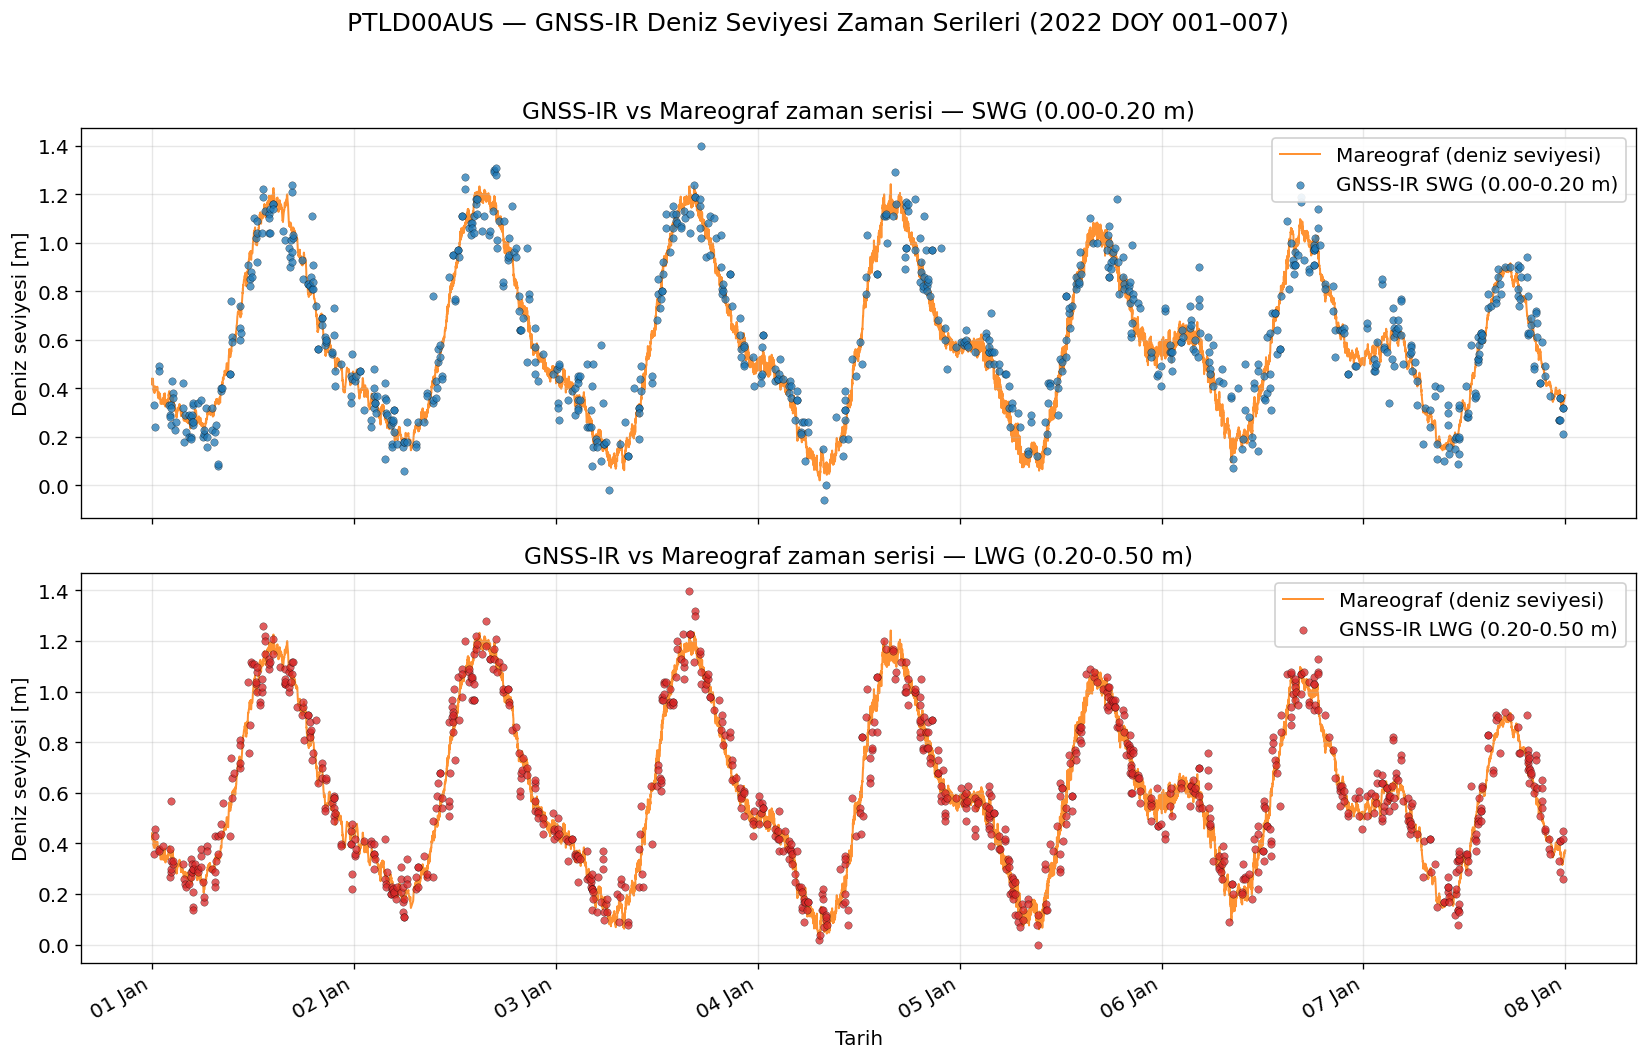

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, group_df, gname, color in (
    (axes[0], swg, "SWG (0.00-0.20 m)", COLOR_SWG),
    (axes[1], lwg, "LWG (0.20-0.50 m)", COLOR_LWG),
):
    # Tide-gauge reference as a continuous light line
    ax.plot(
        tg["epoch"], tg["sea_level"],
        color=COLOR_TG, lw=1.2, alpha=0.85,
        label="Mareograf (deniz seviyesi)", zorder=1,
    )
    # GNSS-IR estimates overlaid as scatter
    ax.scatter(
        group_df["epochMean"], group_df["sea_level_gnssir"],
        s=20, color=color, alpha=0.75, edgecolor="k", linewidth=0.2,
        label=f"GNSS-IR {gname}", zorder=2,
    )
    ax.set_ylabel("Deniz seviyesi [m]")
    ax.set_title(f"GNSS-IR vs Mareograf zaman serisi — {gname}")
    ax.legend(loc="upper right")

axes[1].set_xlabel("Tarih")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
fig.autofmt_xdate()
fig.suptitle(
    "PTLD00AUS — GNSS-IR Deniz Seviyesi Zaman Serileri (2022 DOY 001–007)",
    fontsize=15, y=0.98,
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / f"timeseries_swg_lwg{QC_TAG}.png", bbox_inches="tight")
plt.show()

## 6. Saçılım Grafiği ve Regresyon

GNSS-IR deniz seviyesi (**yatay eksen**) ile mareograf deniz seviyesi (**düşey eksen**)
arasındaki ilişkiyi saçılım grafiğiyle inceliyoruz. Her grup için:

- **1:1 doğrusu** (mükemmel uyum referansı) kesikli olarak çizilir.
- **Doğrusal regresyon** (`y = eğim·x + sabit`) uydurulur; ideal durumda eğim ≈ 1'dir.
- Grafik başlığında eğim, \(R^2\) ve korelasyon katsayısı (r) gösterilir.

Eksenler eşit ölçeklidir (`aspect = equal`) ki 1:1 doğrusu ile regresyon doğrusu görsel
olarak karşılaştırılabilsin.

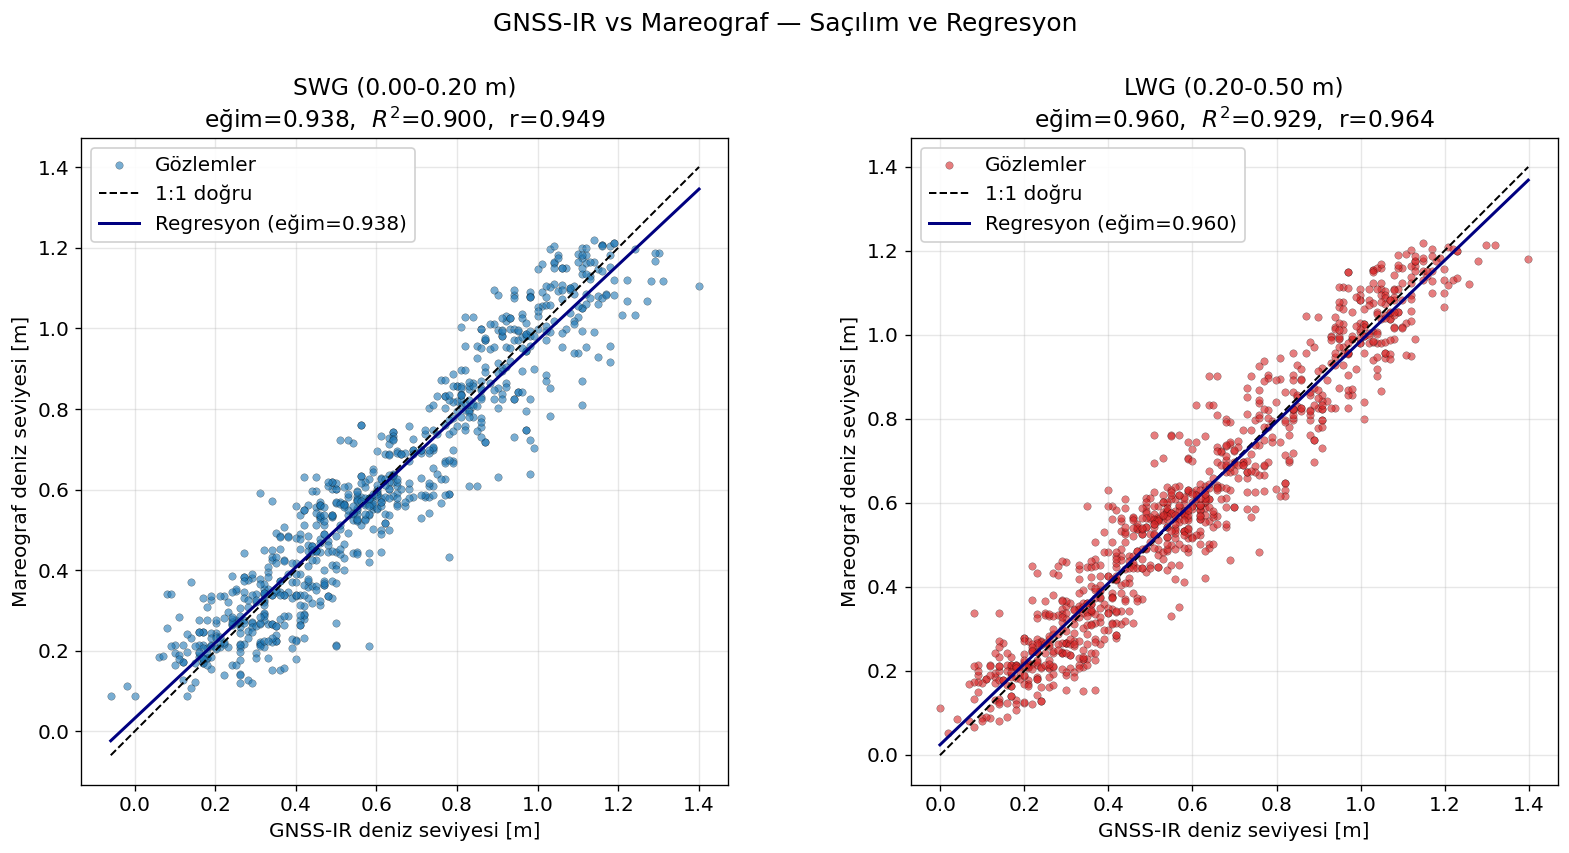

In [7]:
def scatter_with_fit(ax, group_df: pd.DataFrame, gname: str, color: str) -> None:
    """Scatter GNSS-IR (x) vs tide gauge (y) with a 1:1 and regression line."""
    x = group_df["sea_level_gnssir"].to_numpy()
    y = group_df["sea_level_tg"].to_numpy()

    # Linear regression y = slope * x + intercept
    slope, intercept = np.polyfit(x, y, 1)
    r = np.corrcoef(x, y)[0, 1]

    ax.scatter(x, y, s=20, color=color, alpha=0.6, edgecolor="k",
               linewidth=0.2, label="Gözlemler")

    # 1:1 reference line over the common data range
    lim = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lim, lim, "k--", lw=1.2, label="1:1 doğru")

    # Fitted regression line
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color="navy", lw=1.8,
            label=f"Regresyon (eğim={slope:.3f})")

    ax.set_xlabel("GNSS-IR deniz seviyesi [m]")
    ax.set_ylabel("Mareograf deniz seviyesi [m]")
    ax.set_title(f"{gname}\neğim={slope:.3f},  $R^2$={r**2:.3f},  r={r:.3f}")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper left")


fig, axes = plt.subplots(1, 2, figsize=(14, 7))
scatter_with_fit(axes[0], swg, "SWG (0.00-0.20 m)", COLOR_SWG)
scatter_with_fit(axes[1], lwg, "LWG (0.20-0.50 m)", COLOR_LWG)
fig.suptitle("GNSS-IR vs Mareograf — Saçılım ve Regresyon", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / f"scatter_swg_lwg{QC_TAG}.png", bbox_inches="tight")
plt.show()

## 7. İstatistik Tablosu: Korelasyon, KOH (RMSE) ve Bias

Son olarak, GNSS-IR kestirimlerinin mareograf referansına göre doğruluğunu nicel olarak
özetliyoruz. SWG ve LWG için ayrı ayrı:

- **Korelasyon (r)** — İki seri arasındaki doğrusal ilişkinin gücü (Pearson).
- **\(R^2\)** — Açıklanan varyans oranı (\(r^2\)).
- **Regresyon eğimi** — İdeal durumda 1'e yakın olması beklenir.
- **KOH / RMSE [m]** — Karesel ortalama hata: \(\sqrt{\frac{1}{N}\sum (SL_{GNSS\text{-}IR} - SL_{tg})^2}\).
- **Bias / Ortalama hata [m]** — \(\overline{(SL_{GNSS\text{-}IR} - SL_{tg})}\); sistematik bir
  kayma (offset) olup olmadığını gösterir. Sıfıra yakın olması, sistematik bias olmadığı
  anlamına gelir.
- **Std [m]** — Hataların standart sapması (rastgele saçılma).

Fark her zaman **GNSS-IR eksi mareograf** olarak tanımlanır.

In [8]:
def compute_stats(group_df: pd.DataFrame, group_name: str, vlt: float) -> dict:
    """Correlation, RMSE (KOH) and bias of GNSS-IR vs tide-gauge sea level."""
    gnssir = group_df["sea_level_gnssir"].to_numpy()
    tg_lvl = group_df["sea_level_tg"].to_numpy()
    diff = gnssir - tg_lvl  # GNSS-IR minus tide gauge

    slope, _ = np.polyfit(gnssir, tg_lvl, 1)
    r = np.corrcoef(gnssir, tg_lvl)[0, 1]

    return {
        "Grup": group_name,
        "N": len(group_df),
        "VLT [m]": vlt,
        "Korelasyon (r)": r,
        "R^2": r ** 2,
        "Regresyon eğimi": slope,
        "KOH / RMSE [m]": np.sqrt(np.mean(diff ** 2)),
        "Bias / Ortalama hata [m]": np.mean(diff),
        "Std [m]": np.std(diff, ddof=1),
    }


stats_df = pd.DataFrame([
    compute_stats(swg, "SWG (0.00-0.20 m)", VLT_SWG),
    compute_stats(lwg, "LWG (0.20-0.50 m)", VLT_LWG),
]).set_index("Grup")

stats_df_round = stats_df.round(4)
display(stats_df_round)

# Persist the summary table next to the result files
summary_path = RESULTS_DIR / f"final_stats_summary{QC_TAG}.csv"
stats_df_round.to_csv(summary_path)
print(f"Özet tablo kaydedildi: {summary_path}")

,N,VLT [m],Korelasyon (r),R^2,Regresyon eğimi,KOH / RMSE [m],Bias / Ortalama hata [m],Std [m]
Grup,,,,,,,,
SWG (0.00-0.20 m),782,4.9906,0.9489,0.9004,0.9378,0.0972,0.0061,0.0970
LWG (0.20-0.50 m),943,4.8990,0.9640,0.9293,0.9599,0.0814,-0.0007,0.0815


Özet tablo kaydedildi: C:\vscode_workspace\PyReflection\data\results\final_stats_summary_QC.csv


## Sonuç ve Yorum

Bu defter, PTLD00AUS istasyonu için bir haftalık GNSS-IR deniz seviyesi kestirimlerini iki
dalga boyu grubu (SWG ve LWG) için mareograf referansıyla karşılaştırdı:

1. Mareograf verisi GNSS-IR `epochMean` zamanlarına enterpole edildi.
2. Her grup için VLT (APC–TGZ düşey bağlantısı) medyan ile robust biçimde kestirildi.
3. GNSS-IR deniz seviyesi \(SL = \mathrm{VLT} - h\) ile hesaplandı.
4. Zaman serisi ve saçılım grafikleri üretildi.
5. Korelasyon, KOH (RMSE) ve bias değerleri tabloya işlendi.

**Değerlendirme ipuçları:**
- Yüksek korelasyon (r → 1) ve 1'e yakın regresyon eğimi, GNSS-IR'nin gelgit salınımlarını
  iyi takip ettiğini gösterir.
- Düşük KOH (RMSE), kestirimlerin mutlak doğruluğunun yüksek olduğunu işaret eder.
- Sıfıra yakın bias, VLT ile datum bağlantısının başarılı kurulduğunu ve sistematik bir
  kaymanın bulunmadığını gösterir.
- SWG ve LWG metriklerinin karşılaştırılması, hangi dalga boyu grubunun bu istasyon/ortam
  için daha güvenilir sonuç verdiğini ortaya koyar.

> Üretilen şekiller `notebooks/figures/` altına 300 DPI olarak kaydedildi ve doğrudan
> tez/rapora eklenebilir. QC-filtrelenmiş sonuçlarla çalışmak için 2. hücredeki
> `USE_QC = True` yapılması yeterlidir.